In [351]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import lognorm
from tqdm import tqdm
import pandas as pd

### Plotting the Arrivale rates and Lenght of Stay (LOS) for each ward

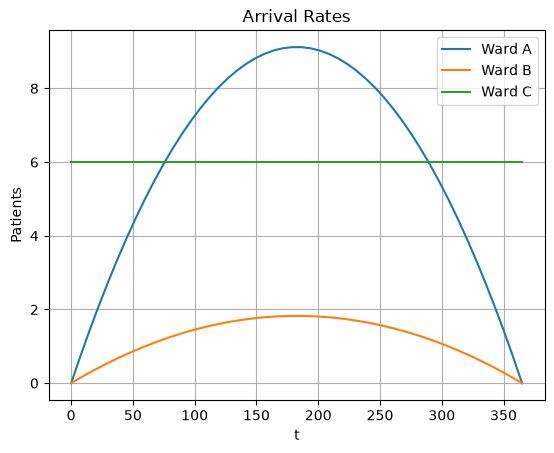

In [352]:
# Simulate time from 0 to 365 days
t = np.linspace(0, 365)

# Arrival rates for ward A, B, C
Arrival_rates = [-(1/3650)*t**2 + (1/10)*t, (1/5)*(-(1/3650)*t**2 + (1/10)*t), np.full_like(t, 6)]

for i in range(len(Arrival_rates)):
    plt.plot(t, Arrival_rates[i],  label=f"Ward {chr(ord('A')+i)}")
    
plt.xlabel('t')
plt.ylabel('Patients')
plt.title('Arrival Rates')
plt.legend()
plt.grid(True)

plt.show()

In [353]:
def arrival_process_poisson(arrival_rate):
    """Sample from a Poisson distribution to simulate the arrival of customers.

    Args:
        arrival_rate (float): The rate of customer arrivals per unit time.

    Returns:
        float: The time until the next customer arrives.
    """
    return np.random.poisson(arrival_rate)

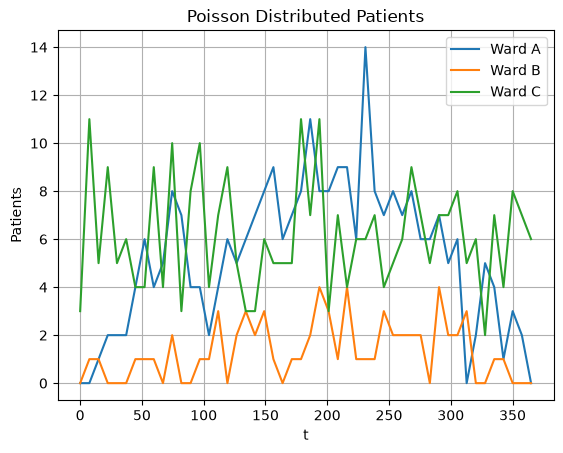

In [354]:
# We plot the amount of patient arriving at the hospital for each ward, each is poisson distributed with the arrival rates given above
ward_a_poisson = np.random.poisson(Arrival_rates[0])
ward_b_poisson = np.random.poisson(Arrival_rates[1])
ward_c_poisson = np.random.poisson(Arrival_rates[2])



for i in range(len(Arrival_rates)):
    plt.plot(t, arrival_process_poisson(Arrival_rates[i]),  label=f"Ward {chr(ord('A')+i)}")

plt.xlabel('t')
plt.ylabel('Patients')
plt.title('Poisson Distributed Patients')
plt.legend()
plt.grid(True)
plt.show()

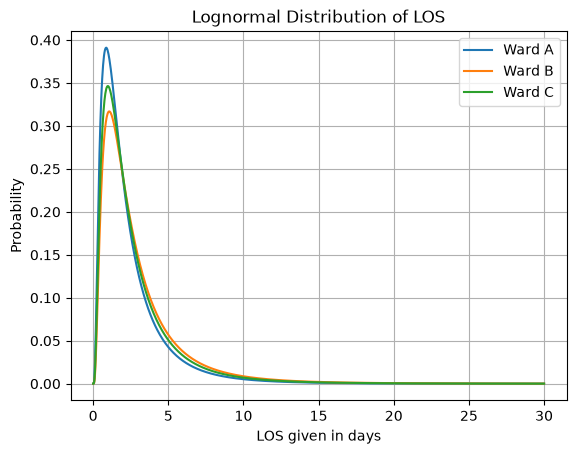

In [355]:
x = np.linspace(0, 30, 1000)  # Range of x values

# Parameters for the lognormal distributions for each Ward
parameters = [
    {'mean': np.log(4*np.sqrt(2)), 'sigma': np.sqrt(np.log(2))},  # A
    {'mean': np.log(6*np.sqrt(2)), 'sigma': np.sqrt(np.log(2))},  # B
    {'mean': np.log(5*np.sqrt(2)), 'sigma': np.sqrt(np.log(2))}   # C
]

for i, param in enumerate(parameters):
    y = lognorm.pdf(x, s=param['sigma'], scale=param['mean'])
    plt.plot(x, y,  label=f"Ward {chr(ord('A')+i)}")

plt.xlabel('LOS given in days')
plt.ylabel('Probability')
plt.title('Lognormal Distribution of LOS')
plt.legend()
plt.grid(True)
plt.show()

In [356]:
def PatientFlowSimulation(capacity, arrival_rates, LOS_mu, LOS_sigma, T):
    """Simulate the flow of patients given a bed distribution, length of stay distribution and a time horizon.

    Args:
        capacity (list): beds available for each ward
        arrival_rates (list): arrival rates for each ward
        LOS_mu (list): mean of the lognormal distribution for length of stay for each ward
        LOS_sigma (list): standard deviation of the lognormal distribution for length of stay for each ward
        T (int): time horizon

    Returns:
        list: beds_occupied, blocked_patients, reallocated_BA, num_patients
    """

    # list of zeroes to init and store used beds
    beds_occupied = np.zeros((len(capacity), T+1))
    # same for blocked patients
    blocked_patients = np.zeros((len(capacity), T+1))
    # reallocated patients from ward B to ward A
    reallocated_BA = np.zeros(T+1)
    # total number of patients of each type 
    num_patients = np.zeros(len(capacity))

    # initialize and store the remaining capacity for each bed type
    beds_left_A = np.zeros(capacity[0])
    beds_left_B = np.zeros(capacity[1])
    beds_left_C = np.zeros(capacity[2])

    # simulate the patient flow for each time step
    for t in range(1, T+1):

        # Ward A
        beds_left_A = [x if x - t > 0 else 0 for x in beds_left_A]
        beds_occupied[0, t] = np.count_nonzero(beds_left_A) 

        # Ward B
        beds_left_B = [x if x - t > 0 else 0 for x in beds_left_B]
        beds_occupied[1, t] = np.count_nonzero(beds_left_B) 

        # Ward C
        beds_left_C = [x if x - t > 0 else 0 for x in beds_left_C]
        beds_occupied[2, t] = np.count_nonzero(beds_left_C)  

        # arrival rates for each ward at time t
        Arrivals_A = arrival_process_poisson(arrival_rates[0][t])
        Arrivals_B = arrival_process_poisson(arrival_rates[1][t])
        Arrivals_C = arrival_process_poisson(arrival_rates[2][t])

        # Update the total number of patients for each bed type
        num_patients += [Arrivals_A, Arrivals_B, Arrivals_C]

        # Check if there are enough beds and relocated
        

        # Ward B
        if Arrivals_B + beds_occupied[1, t] > capacity[1]:
            reallocated_BA[t] += Arrivals_B + beds_occupied[1, t] - capacity[1]  
            beds_occupied[1, t] = capacity[1]  
        else:
            beds_occupied[1, t] = beds_occupied[1, t] + Arrivals_B 

        # Ward A
        if Arrivals_A + reallocated_BA[t] + beds_occupied[0, t] > capacity[0]:
            blocked_patients[0, t] += Arrivals_A + reallocated_BA[t] + beds_occupied[0, t] - capacity[0]  
            beds_occupied[0, t] = capacity[0] 
        else:
            beds_occupied[0, t] = beds_occupied[0, t] + Arrivals_A + reallocated_BA[t]  


        # Ward C
        if Arrivals_C + beds_occupied[2, t] > capacity[2]:
            blocked_patients[2, t] += Arrivals_C + beds_occupied[2, t] - capacity[2]  
            beds_occupied[2, t] = capacity[2]  
        else:
            beds_occupied[2, t] = beds_occupied[2, t] + Arrivals_C 

        # Generate the time of stay for new patients and update the remaining time for occupied beds
        # Ward A
        beds_stay_A = np.random.lognormal(LOS_mu[0], LOS_sigma[0], int(Arrivals_A + reallocated_BA[t] - blocked_patients[0, t])) + t
        beds_left_A = sorted(beds_left_A)
        beds_left_A[0:len(beds_stay_A)] = beds_stay_A

        # Ward B
        beds_stay_B = np.random.lognormal(LOS_mu[1], LOS_sigma[1], int(Arrivals_B - reallocated_BA[t])) + t
        beds_left_B = sorted(beds_left_B)
        beds_left_B[0:len(beds_stay_B)] = beds_stay_B

        # Ward C
        beds_stay_C = np.random.lognormal(LOS_mu[2], LOS_sigma[2], int(Arrivals_C - blocked_patients[2, t])) + t
        beds_left_C = sorted(beds_left_C)
        beds_left_C[0:len(beds_stay_C)] = beds_stay_C
    

 
    return beds_occupied, blocked_patients, reallocated_BA, num_patients

In [357]:
T = 365
t = np.arange(T+1)
cap = [25, 25, 25]
arrival_rates = [-(1/3650)*t**2 + (1/10)*t, (1/5)*(-(1/3650)*t**2 + (1/10)*t), np.full_like(t, 6)]
mu = [np.log(4 * np.sqrt(2)), np.log(6 * np.sqrt(2)), np.log(5 * np.sqrt(2))]
sigma = [np.log(2), np.log(2), np.log(2)]

occupied, Rejected, Reallocated, no_patients = PatientFlowSimulation(cap, arrival_rates, mu, sigma, T)

In [358]:
# Calculate that all beds are occupied
mnA = np.sum(Rejected[0]) / no_patients[0]
mnB = np.sum(Reallocated) / no_patients[1]
mnC = np.sum(Rejected[2]) / no_patients[2]

print("Number of patients in each Ward = ", no_patients)
print("Number of rejections in each ward =",[np.sum(Rejected[0]), np.sum(Reallocated), np.sum(Rejected[2])])
print("The probability for all beds being occupied =", [mnA, mnB, mnC])
print("The mean patients for all beds being occupied =", [np.mean(occupied[0, :366]), np.mean(occupied[1, :366]), np.mean(occupied[2, :366])])
print("Total number of blockings: ", np.sum(Rejected[0]) + np.sum(Reallocated) + np.sum(Rejected[2]))
print("Mean fraction of beds occupied in each ward: ", [np.mean(occupied[0, :366]) / cap[0], np.mean(occupied[1, :366]) / cap[1], np.mean(occupied[2, :366]) / cap[2]])

Number of patients in each Ward =  [2188.  429. 2150.]
Number of rejections in each ward = [np.float64(1094.0), np.float64(0.0), np.float64(1163.0)]
The probability for all beds being occupied = [np.float64(0.5), np.float64(0.0), np.float64(0.5409302325581395)]
The mean patients for all beds being occupied = [np.float64(22.188524590163933), np.float64(13.147540983606557), np.float64(24.57103825136612)]
Total number of blockings:  2257.0
Mean fraction of beds occupied in each ward:  [np.float64(0.8875409836065573), np.float64(0.5259016393442623), np.float64(0.9828415300546447)]


<Axes: >

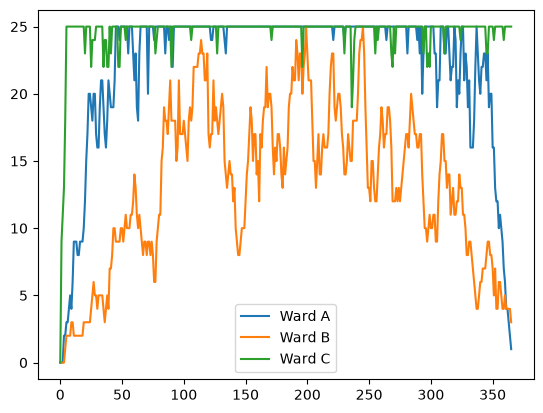

In [359]:
occupied_df = pd.DataFrame(occupied.T, columns=['Ward A', 'Ward B', 'Ward C'])
occupied_df.plot()

<Axes: >

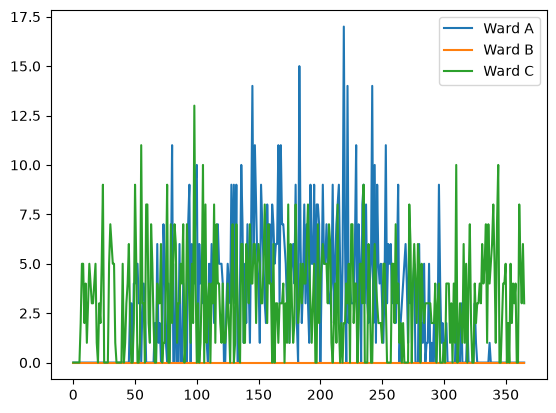

In [360]:
rejected_df = pd.DataFrame(Rejected.T, columns=['Ward A', 'Ward B', 'Ward C'])
rejected_df.plot()

In [361]:
# best_cap = None
# min_total_relocations = float('inf')
# num_runs = 5 
# total_beds = 75

# # gried search over all possible combinations of bed distributions for the three wards
# for cap_A in tqdm(range(total_beds + 1)):
#     for cap_B in range(total_beds - cap_A + 1):
#         cap_C = total_beds - cap_A - cap_B
#         cap = [cap_A, cap_B, cap_C]
        
#         runs_metric = np.zeros(num_runs)
        
#         for i in range(num_runs):
#             occupied, Rejected, Reallocated, no_patients = PatientFlowSimulation(cap, arrival_rates, mu, sigma, T)
            
#             # rejected + reallocated
#             runs_metric[i] = np.sum(Rejected) + np.sum(Reallocated)
            
#         mean_total_relocations = np.mean(runs_metric)
        
#         # update new best solution
#         if mean_total_relocations < min_total_relocations:
#             min_total_relocations = mean_total_relocations
#             best_cap = cap


# print(f"Optimal Capacity Distribution: Ward A: {best_cap[0]}, Ward B: {best_cap[1]}, Ward C: {best_cap[2]}")
# print(f"Minimum Mean (Rejected + Reallocated): {min_total_relocations}")